In [71]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import torch

url = "https://raw.githubusercontent.com/PhilChodrow/ml-notes/main/data/palmer-penguins/palmer-penguins.csv"
df = pd.read_csv(url)
df = df.dropna(subset=['Culmen Length (mm)', 'Culmen Depth (mm)', 'Species'])
df = df[['Culmen Length (mm)', 'Culmen Depth (mm)', 'Species']]
df["Species"] = df["Species"].str.split().str[0]

X = df[['Culmen Length (mm)', 'Culmen Depth (mm)']].values
labels = df['Species'].astype('category')
label_map = {label: idx for idx, label in enumerate(df['Species'].unique())}

df.head()

,Culmen Length (mm),Culmen Depth (mm),Species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
4,36.7,19.3,Adelie
5,39.3,20.6,Adelie


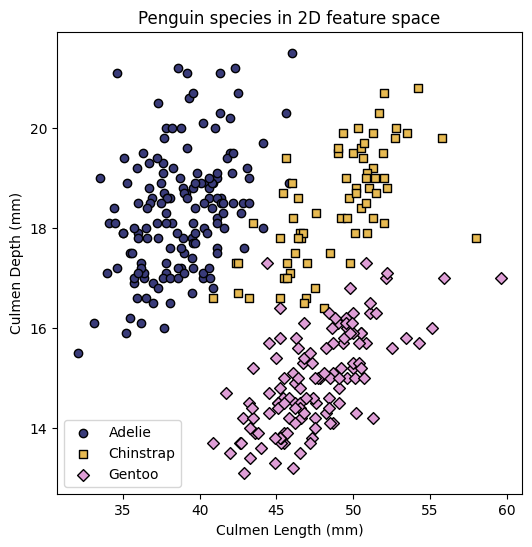

In [72]:
def scatter_points(X, labels, cmap, ax): 
    if isinstance(labels, torch.Tensor):
        y = labels
        unique_labels = torch.unique(y.detach())
    else:
        y = labels.cat.codes.values
        unique_labels = labels.cat.categories
    
    for i, label in enumerate(unique_labels):
        color = cmap(i)
        marker = ['o', 's', 'D'][i]
        ax.scatter(X[y == i, 0], 
                   X[y == i, 1], 
                   color=color, 
                   edgecolor='k', 
                   marker=marker, 
                   label=f"{unique_labels[i]}", 
                   zorder = 1e3)
    
    ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$")
    ax.legend().set_zorder(1e7)

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.get_cmap('tab20b', 3)
scatter_points(X, labels, cmap, ax)
ax.set_title("Penguin species in 2D feature space")
ax.set_xlabel("Culmen Length (mm)")
t = ax.set_ylabel("Culmen Depth (mm)")

**Find best culmen length split**

We can step through some possible culmen length values, calculate the information gain for each split, and store the best split value.

In [73]:
from decision_tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()

parent = df["Species"]

best_depth_split_mm = None 
best_depth_split_info_gain = 0

for mm in range(30, 65, 1):
    left = df[df["Culmen Length (mm)"] < mm]["Species"]
    right = df[df["Culmen Length (mm)"] >= mm]["Species"]

    if (classifier.information_gain(parent, left, right) > best_depth_split_info_gain):
        best_depth_split_mm = mm 
        best_depth_split_info_gain = classifier.information_gain(parent, left, right)

print(f"Best culmen length split mm: {best_depth_split_mm}")
print(f"Best culmen length info gain: {best_depth_split_info_gain}")


Best culmen length split mm: 43
Best culmen length info gain: 0.2996579511186297


The best mm to split at for culmen length is 43, which provides 0.299 information gain. We can plot what that split looks like:

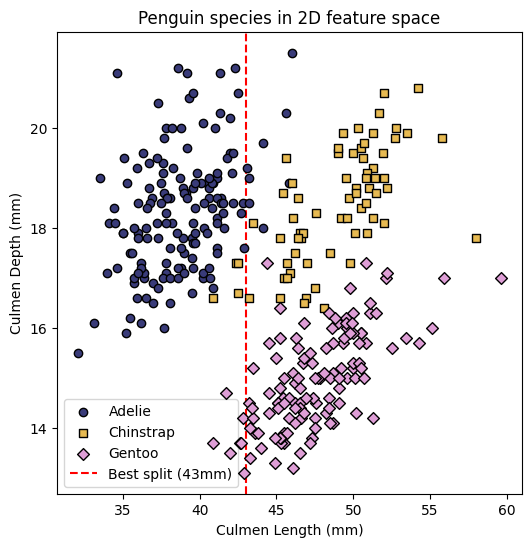

In [74]:
fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.get_cmap('tab20b', 3)
scatter_points(X, labels, cmap, ax)
ax.axvline(x=best_depth_split_mm, color='red', linestyle='--', label=f'Best split ({best_depth_split_mm}mm)')
ax.set_title("Penguin species in 2D feature space")
ax.set_xlabel("Culmen Length (mm)")
ax.set_ylabel("Culmen Depth (mm)")
ax.legend()

Now we can try finding the best culmen depth split on the right half of the data above:

In [75]:
# Update parent to be right half of our split
df_split = df[df["Culmen Length (mm)"] >= best_depth_split_mm]
parent = df_split["Species"]
best_length_split_mm = None 
best_length_split_info_gain = 0

for mm in range(10, 24, 1):
    left = df_split[df_split["Culmen Depth (mm)"] < mm]["Species"]
    right = df_split[df_split["Culmen Depth (mm)"] >= mm]["Species"]

    if (classifier.information_gain(parent, left, right) > best_length_split_info_gain):
        best_length_split_mm = mm 
        best_length_split_info_gain = classifier.information_gain(parent, left, right)

print(f"Best culmen depth split mm: {best_length_split_mm}")
print(f"Best culmen depth info gain: {best_length_split_info_gain}")

Best culmen depth split mm: 17
Best culmen depth info gain: 0.3139876229080269


17mm is our best split for culmen depth on the right side of the decision boundary seen above. Let's plot it:

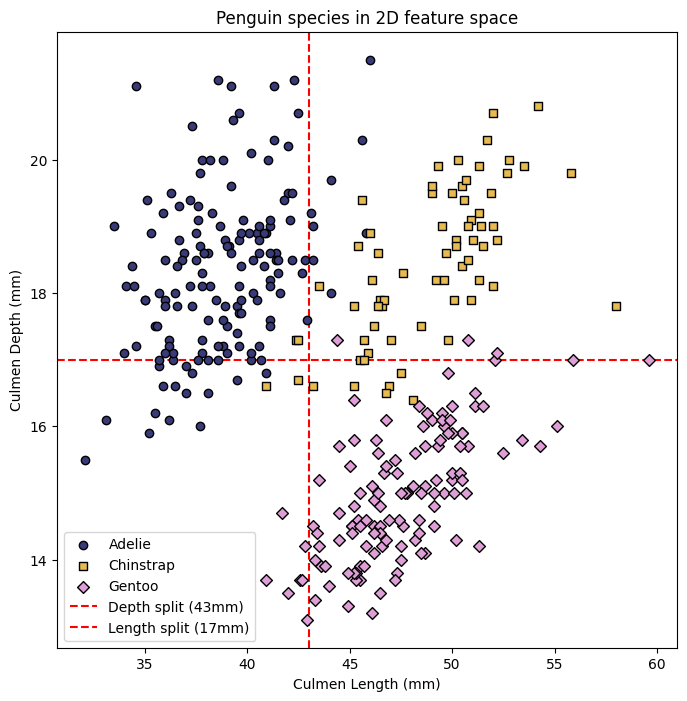

In [76]:
fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.get_cmap('tab20b', 3)
scatter_points(X, labels, cmap, ax)
ax.axvline(x=best_depth_split_mm, color='red', linestyle='--', label=f'Depth split ({best_depth_split_mm}mm)')
ax.axhline(y=best_length_split_mm, color='red', linestyle='--', label=f'Length split ({best_length_split_mm}mm)')
ax.set_title("Penguin species in 2D feature space")
ax.set_xlabel("Culmen Length (mm)")
ax.set_ylabel("Culmen Depth (mm)")
ax.legend()